#Follower Growth Signals

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from pathlib import Path

data_path = Path('../data/exports')

master_df = pd.read_csv(data_path / 'master_df.csv')

In [12]:
print("All Columns in your master_df / main_df:")
print("="*60)
for i, col in enumerate(sorted(master_df.columns), 1):
    print(f"{i:2d}. {col}")

All Columns in your master_df / main_df:
 1. created_dat
 2. created_time
 3. engagement_per_follower
 4. followers_received
 5. following_count
 6. hashtag_count
 7. hashtags
 8. id
 9. image_link
10. insta_filter_used
11. name
12. photo_type
13. post_count
14. private/public
15. total_comments
16. total_engagement
17. total_likes
18. user_id
19. verified_status


In [20]:
growth_df = master_df.copy()

# ===================== FOLLOWERS GROWTH SIGNALS =====================
# =========================================================================
# Convert to datetime


growth_df['created_time'] = pd.to_datetime(growth_df['created_time'], errors='coerce')
growth_df = growth_df.sort_values('created_time')

# Follower Growth Calculation
growth_df['prev_follower_count'] = growth_df.groupby('user_id')['followers_received'].shift(1)
growth_df['follower_growth'] = growth_df['followers_received'] - growth_df['prev_follower_count']

print("FOLLOWER GROWTH SIGNALS ANALYSIS")


# Overall Statistics
print(f"Total Posts Analyzed              : {len(growth_df):,}")
print(f"Posts with Follower Growth Data   : {growth_df['follower_growth'].notna().sum():,}")
print(f"Average Follower Growth per Post  : {growth_df['follower_growth'].mean():.2f}")
print(f"Maximum Follower Growth           : {growth_df['follower_growth'].max():.0f}")
print(f"Minimum Follower Growth           : {growth_df['follower_growth'].min():.0f}")

# ===================== Correlation Analysis =====================
cols_for_corr = ['total_engagement', 'engagement_per_follower', 'total_likes', 
                 'total_comments', 'hashtag_count', 'follower_growth']

correlation = growth_df[cols_for_corr].corr()

print("\n-_-Correlation with Follower Growth:")
display(correlation['follower_growth'].sort_values(ascending=False).round(3))

FOLLOWER GROWTH SIGNALS ANALYSIS
Total Posts Analyzed              : 257
Posts with Follower Growth Data   : 183
Average Follower Growth per Post  : 0.00
Maximum Follower Growth           : 0
Minimum Follower Growth           : 0

-_-Correlation with Follower Growth:


total_engagement          NaN
engagement_per_follower   NaN
total_likes               NaN
total_comments            NaN
hashtag_count             NaN
follower_growth           NaN
Name: follower_growth, dtype: float64

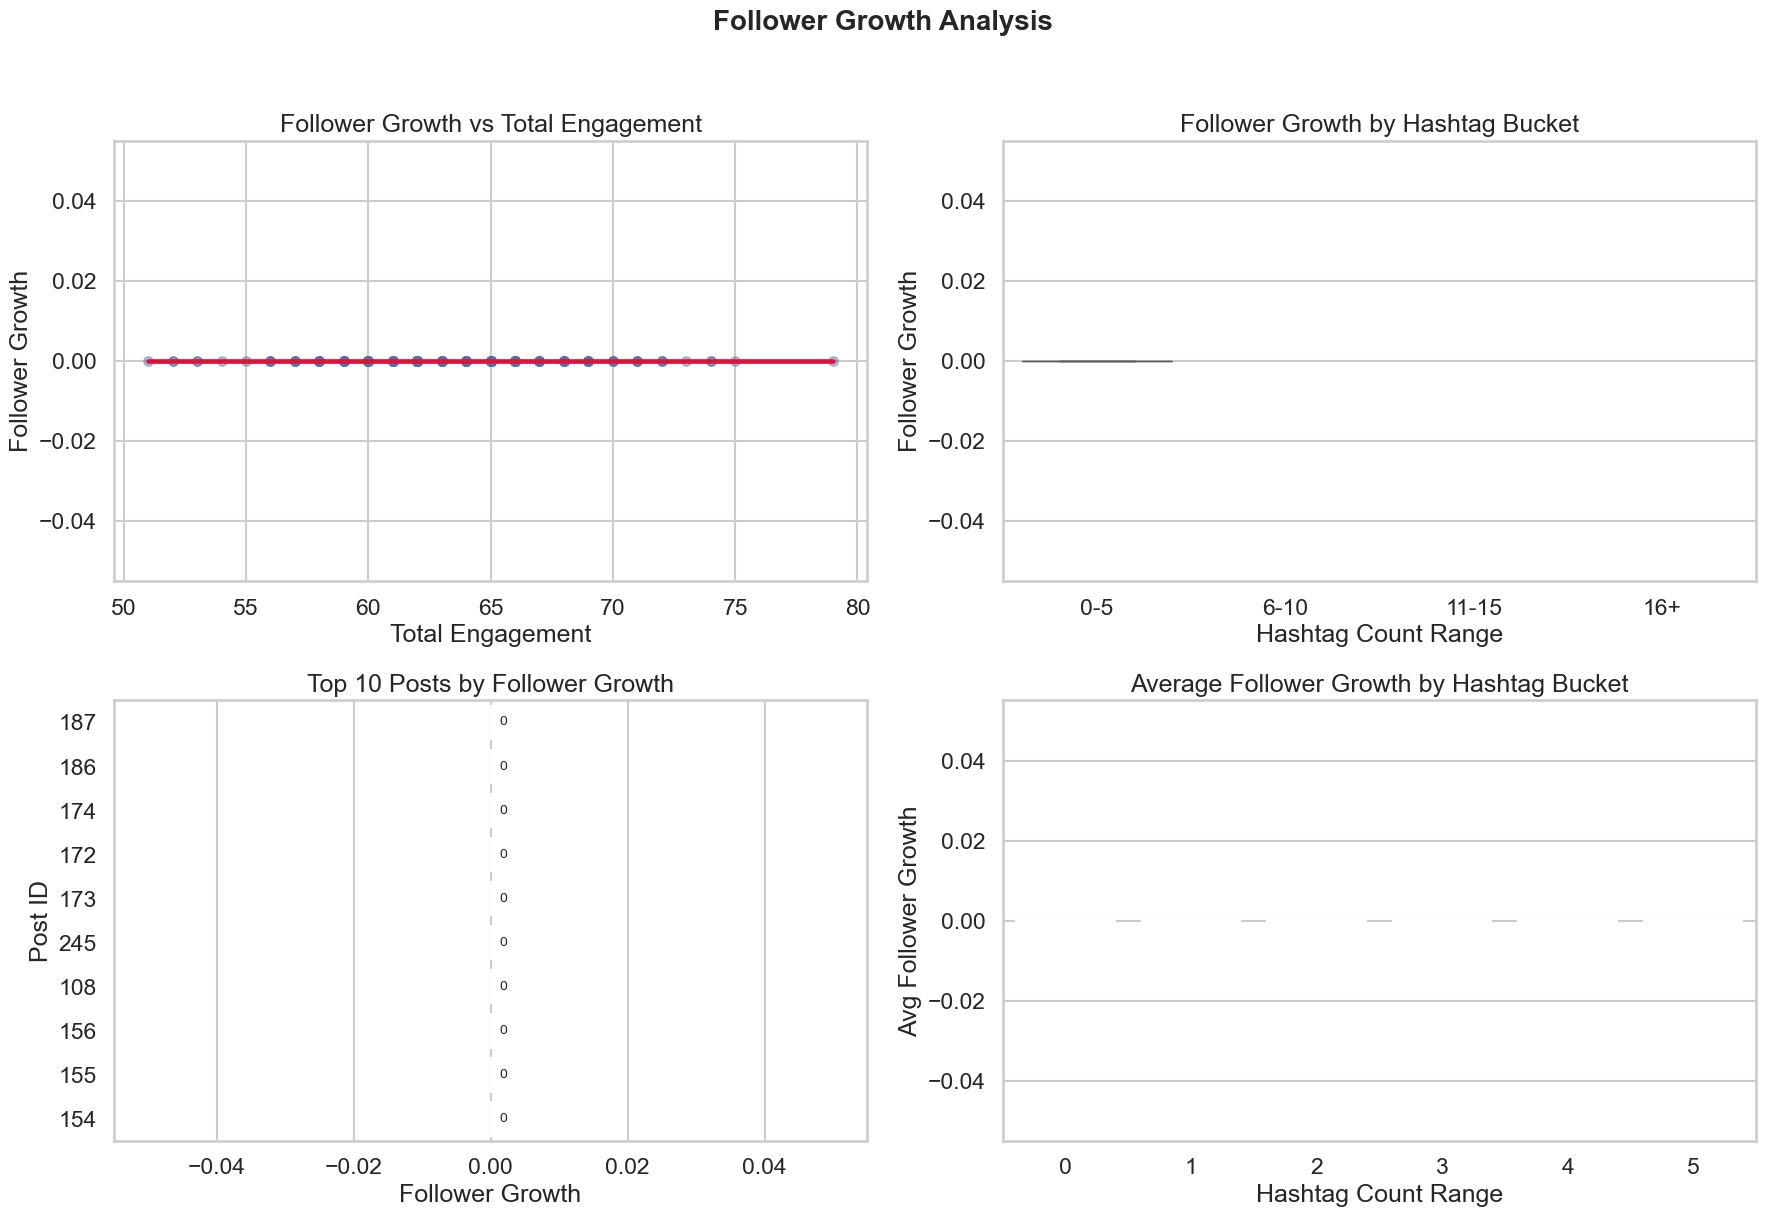

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure the post identifier exists for plotting
if 'photo_id' not in growth_df.columns:
    if 'id' in growth_df.columns:
        growth_df['photo_id'] = growth_df['id']
    else:
        growth_df['photo_id'] = range(1, len(growth_df) + 1)

# Create easy-to-read hashtag buckets for plotting
growth_df['hashtag_bucket'] = pd.cut(
    growth_df['hashtag_count'],
    bins=[-1, 5, 10, 15, float('inf')],
    labels=['0-5', '6-10', '11-15', '16+']
)

sns.set_theme(style='whitegrid', context='talk')
plt.figure(figsize=(18, 12))

# 1. Scatter: Engagement vs Follower Growth
plt.subplot(2, 2, 1)
sns.regplot(data=growth_df, x='total_engagement', y='follower_growth', scatter_kws={'alpha': 0.45, 's': 45}, line_kws={'color': 'crimson'})
plt.title('Follower Growth vs Total Engagement')
plt.xlabel('Total Engagement')
plt.ylabel('Follower Growth')

# 2. Box Plot: Follower Growth by Hashtag Bucket
plt.subplot(2, 2, 2)
sns.boxplot(data=growth_df, x='hashtag_bucket', y='follower_growth', palette='Set2')
plt.title('Follower Growth by Hashtag Bucket')
plt.xlabel('Hashtag Count Range')
plt.ylabel('Follower Growth')

# 3. Top Posts that drove follower growth
plt.subplot(2, 2, 3)
top_growth = growth_df.nlargest(10, 'follower_growth').copy()
top_growth['post_label'] = top_growth['photo_id'].astype(str)
sns.barplot(data=top_growth, y='post_label', x='follower_growth', orient='h', palette='Blues_r')
plt.title('Top 10 Posts by Follower Growth')
plt.xlabel('Follower Growth')
plt.ylabel('Post ID')

# Annotate bars for readability
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.0f}', (width, p.get_y() + p.get_height() / 2),
                xytext=(6, 0), textcoords='offset points', va='center', fontsize=10)

# 4. Average follower growth by hashtag bucket
plt.subplot(2, 2, 4)
bucket_summary = growth_df.groupby('hashtag_count', observed=True)['follower_growth'].mean().reset_index()
sns.barplot(data=bucket_summary, x='hashtag_count', y='follower_growth', palette='magma')
plt.title('Average Follower Growth by Hashtag Bucket')
plt.xlabel('Hashtag Count Range')
plt.ylabel('Avg Follower Growth')

plt.suptitle('Follower Growth Analysis', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()